In [1]:

import scanpy as sc
import pandas as pd
from pathlib import Path
import gzip


In [2]:
adata=sc.read_h5ad('Data/combined_raw.h5ad')

c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
#5. QC filtering
# Basic filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Mitochondrial gene filter
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

adata = adata[adata.obs.pct_counts_mt < 5, :]  # Keep cells with <5% mito reads
print(f"After QC: {adata.shape}")


c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


After QC: (14746, 22519)


In [4]:
#Normalization and log transformation 
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\prath\Downloads\ScRnaseq_research\venv\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [16]:
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)

In [17]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata)

In [11]:
output_path = Path("Data/adata_raw_qc.h5ad")
adata.write(output_path)
print(f"Saved AnnData object to {output_path}")


Saved AnnData object to Data\adata_raw_qc.h5ad


In [7]:
adata

AnnData object with n_obs × n_vars = 14746 × 2000
    obs: 'sample', 'title', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.tissue', 'characteristics_ch1.1.subject status', 'molecule_ch1', 'extract_protocol_ch1', 'description', 'data_processing', 'platform_id', 'contact_email', 'contact_phone', 'contact_department', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'supplementary_file_1', 'supplementary_file_2', 'supplementary_file_3', 'series_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'gene_symbol', 'ensembl_id', 'feature_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    

In [8]:
!pip3 install igraph

In [9]:
!pip3 install leidenalg

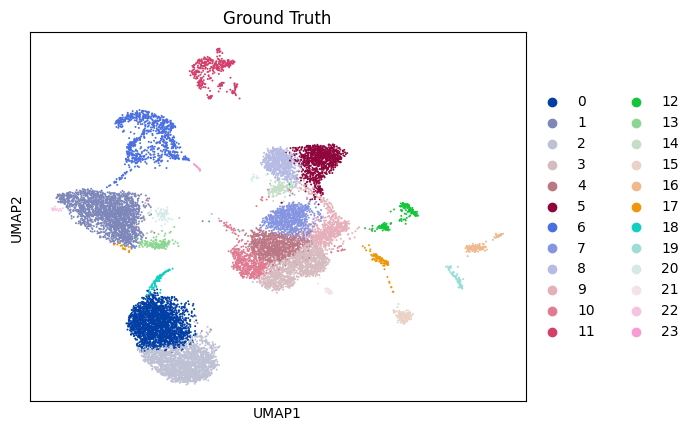

In [18]:
sc.pl.umap(adata, color='leiden', title='Ground Truth', save='_GT_UMAP.png')

In [23]:
# Use gene_symbol as var_names
adata.var['gene_symbol'] = adata.var['gene_symbol'].astype(str)  # convert from object
adata.var_names = adata.var['gene_symbol']

In [ ]:
# Use gene_symbol column as var_names
adata.var['gene_symbol'] = adata.var['gene_symbol'].astype(str)

# Clean list-like strings e.g. "['CD34']"
adata.var['gene_symbol'] = adata.var['gene_symbol'].str.replace("[\[\]']", "", regex=True)

# Set gene_symbol as index
adata.var_names = adata.var['gene_symbol']
adata.var_names_make_unique() 
